In [1]:
import numpy as np
from matplotlib import pyplot as plt
from IPython import display
from scipy.interpolate import BSpline, make_lsq_spline
import matplotlib.patches as patches
import matplotlib.transforms as mtransforms

class DiffRobot:
    A = np.array([[1.0, 0, 0],
                  [0, 1.0, 0],
                  [0, 0, 1.0]])  # Class-level constant

    def __init__(self, dt, s=[0, 0, 0]):
        self.dt = dt  # Sampling period
        self.max_linear_vel = 0.20  # m/s
        self.max_angular_vel = 2.0  # rad/s
        self.s = np.array(s, dtype=np.float64)
        self.s_pre = np.zeros_like(self.s)
        self.v = 0.0  # Linear velocity
        self.B = None  # Updated dynamically

    def move_by_state_space(self, u_pre, yaw):
        self.s_pre = self.s

        # Precompute cosine and sine of yaw
        cos_yaw = np.cos(yaw)
        sin_yaw = np.sin(yaw)

        # Update B matrix
        self.B = np.array([[cos_yaw * self.dt, 0],
                           [sin_yaw * self.dt, 0],
                           [0, self.dt]])

        # Clip control inputs
        u_pre = np.clip(u_pre, [-self.max_linear_vel, -self.max_angular_vel],
                        [self.max_linear_vel, self.max_angular_vel])

        # Update state
        self.s = (self.A @ self.s_pre) + (self.B @ u_pre)

        # Compute velocity
        self.v = np.linalg.norm(self.s[:2] - self.s_pre[:2]) / self.dt

    def get_state(self):
        return self.s

    def get_last_state(self):
        return self.s_pre

    def get_velocity(self):
        return self.v

class Controller:
    
    def __init__(self, robot, predecessor, params) -> None:
        # Basic gains
        self.alpha = params["a"]
        self.alpha_angle = params["aa"]
        # Additional gains for DSR
        self.beta1 = params["b1"]
        self.beta2 = params["b2"]
        # System parameters 
        self.tau = params["tau"]
        self.spacing = params["d"]
        # System memories
        self.error_last = 0.0
        self.input = np.zeros(2, dtype=np.float64)
        self.target_last = robot.s[:2]
        self.state_last = robot.s[:2]
        self.linear_fb_last = 0.0
        # DSR specific memories
        self.t_d_last = 0.0
        self.s_d_last = 0.0
        self.e_d_last = 0.0
        self.r_t_last = 0.0

        # Camera observations 
        self.observations = self._interp_traj(robot.s[:2], 
                                              predecessor.s[:2])
        
        # Predecessor estimated trajectory params
        self.fit_trajectory = np.array(self.observations)
        self.derivatives = {
            "dx_dt" : 0.0,
            "ddx_dt": 0.0,
            "dy_dt" : 0.0,
            "ddy_dt": 0.0,
        }

        # System limits
        self.max = 0.2
        self.min = -0.2

    def _low_pass(self, x, x_last, lp_gain = 0.2):
        return lp_gain * x + (1 - lp_gain) * x_last 

    def _check_limits(self, input):
        return np.clip(input, self.min, self.max)
        
    def _smooth_arctan2(self, angle):
        if angle > np.pi:
                angle -= 2*np.pi
        elif angle < -np.pi:
                angle += 2*np.pi

        return angle
    
    def _angular_gain_map(self, velocity, threshold):
        if np.abs(velocity) <= threshold:
            return 0.0
        else:
            return self.alpha_angle
        
    def _interp_traj(self, state, leader_state, pts = 300):
        """
        Interpolate a initial trajectory between the follower and predecessor.
        """
        start = np.array(state)
        end = np.array(leader_state)
        vector = start - end

        return np.linspace(start + vector, end, pts).tolist()
    
    def _signed_error(self, state, target, heading_rad):
        """
        Compute the signed magnitude using the dot product
        """
        error_vector = target - state
        reference = np.array([np.cos(heading_rad), np.sin(heading_rad)])

        magnitude = np.linalg.norm(error_vector)
        sign = np.sign(np.dot(error_vector, reference)) 

        return magnitude * sign
    
    def _get_fit_states(self, predecessor_states, state, stablizing_tail = 10):
        """
        Select the states to fit the predecessor path
        """
        # Closest predecessor state to follower + the stablizing tail 
        distances = np.sum((predecessor_states - state) ** 2, axis=1)
        start_idx = max(np.argmin(distances) - stablizing_tail, 0)
        fit_states = np.array(predecessor_states[start_idx:])
        
        # Trim the observations to save memory
        if start_idx > 50:
            self.observations = predecessor_states[(start_idx - 50):]
        else:
            self.observations = predecessor_states[:]

        return fit_states, stablizing_tail
        
    def fit_poly_trajectory(self, predecessor_states: list, 
                            state: list, degree: int, 
                            weight_factor: float = 10.0):
        """
        Fit a weighted polynomial trajectory using predecessor's observed states.
        Compute the first and second derivatives at a parameter value t_query.
        """
        fit_states, query_indx = self._get_fit_states(predecessor_states, state)

        # Set up the weighted least squares problem & Vandermonde matrix
        n_fit_states = len(fit_states)
        t = np.linspace(0, 1, n_fit_states)
        V = np.vander(t, degree + 1, increasing=True)  

        # Create weights: higher weight for the closest state
        weights = np.ones(n_fit_states, dtype=np.float32)
        weights[0] = weight_factor

        # Solve (W @ V) @ coeffs = W @ observed_values 
        # (Element-wise multiplication for performance reason)
        W = weights[:, np.newaxis]
        WV = W * V 
        Wx = W[:, 0] * fit_states[:, 0]
        Wy = W[:, 0] * fit_states[:, 1]
        x_coeffs = np.linalg.lstsq(WV, Wx, rcond=None)[0]
        y_coeffs = np.linalg.lstsq(WV, Wy, rcond=None)[0]

        # Reconstruct the polynomial trajectory (x_coeffs[::-1] high to low deg)
        t_traj = np.linspace(0, 1, len(predecessor_states))
        x_traj = np.polyval(x_coeffs[::-1], t_traj)
        y_traj = np.polyval(y_coeffs[::-1], t_traj)
        self.fit_trajectory = np.column_stack([x_traj, y_traj])

        # Compute derivatives at t_query
        deriv_powers = np.arange(degree, 0, -1)
        dx_coeffs = deriv_powers * x_coeffs[::-1][:-1]
        dy_coeffs = deriv_powers * y_coeffs[::-1][:-1]
        ddx_coeffs = (deriv_powers - 1)[:-1] * dx_coeffs[:-1]
        ddy_coeffs = (deriv_powers - 1)[:-1] * dy_coeffs[:-1]

        # Evaluate derivatives at t_query
        t_query = t[query_indx]
        t_powers = t_query ** np.arange(degree)
        self.derivatives = {
            "dx_dt": np.dot(dx_coeffs[::-1], t_powers),
            "ddx_dt": np.dot(ddx_coeffs[::-1], t_powers[:-1]),
            "dy_dt": np.dot(dy_coeffs[::-1], t_powers),
            "ddy_dt": np.dot(ddy_coeffs[::-1], t_powers[:-1])
        }

    def fit_bspline_trajectory(self, predecessor_states: list, 
                               state: list, degree: int, 
                               num_knots: int):
        """
        Fit a B-spline trajectory using predecessor's observed states.
        Compute the first and second derivatives at a parameter value t_query.
        """
        fit_states, query_indx = self._get_fit_states(predecessor_states, state)
        
        # Normalize time parameter
        n_fit_states = len(fit_states)
        t = np.linspace(0, 1, n_fit_states)

        # Create knot vector for B-spline
        knots = np.linspace(0, 1, num_knots)  # Uniform knot spacing
        t_augmented = np.concatenate(([0] * degree, knots, [1] * degree))  # Augmented ends for degree
        
        # Fit B-spline using least squares
        x_spline = make_lsq_spline(t, fit_states[:, 0], t_augmented, degree)
        y_spline = make_lsq_spline(t, fit_states[:, 1], t_augmented, degree)

        # Reconstruct the B-spline trajectory
        t_traj = np.linspace(0, 1, len(predecessor_states))
        x_traj = x_spline(t_traj)
        y_traj = y_spline(t_traj)
        self.fit_trajectory = np.column_stack([x_traj, y_traj])

        # Compute derivatives at t_query
        t_query = t[query_indx]
        self.derivatives = {
            "dx_dt": x_spline.derivative(nu=1)(t_query),
            "ddx_dt": x_spline.derivative(nu=2)(t_query),
            "dy_dt": y_spline.derivative(nu=1)(t_query),
            "ddy_dt": y_spline.derivative(nu=2)(t_query) 
        }

    def traj_angular_update(self, target, robot):
        """
        Compute regular angular input from trajectory
        """
        dx_dt = self.derivatives["dx_dt"]
        ddx_dt = self.derivatives["ddx_dt"]
        dy_dt = self.derivatives["dy_dt"]
        ddy_dt = self.derivatives["ddy_dt"]

        # Compute feedforward 
        v_t = robot.v
        v_tau = np.sqrt(dx_dt ** 2 + dy_dt **2)
        tau_d = v_t / v_tau if v_tau > 0 else 0
        angular_ff = tau_d * ((ddy_dt * dx_dt) - (ddx_dt * dy_dt)) / (v_tau ** 2)

        # Compute feedback
        angle = robot.s[2]
        traj_angle = (np.arctan2(dy_dt, dx_dt) + 2 * np.pi) % (2 * np.pi)
        angle_error = self._smooth_arctan2(traj_angle - angle)
        angular_fb = self._angular_gain_map(robot.v, 0.01) * angle_error

        return angular_ff + angular_fb

    def angular_update(self, target, robot):
        """
        Compute regular angular input from target
        """
        state = robot.s[:2]
        angle = robot.s[2]
        target_angle = np.arctan2(target[1] - state[1],
                                  target[0] - state[0])
        angle_error = self._smooth_arctan2(target_angle - angle)
        angular_fb = self._angular_gain_map(robot.v, 0.01) * angle_error

        return angular_fb

    def P_update(self, target, robot):
        """
        Compute regular linear input
        v_i(t) = alpha * error
        """
        state = robot.s[:2]
        heading = robot.s[2]
        error = self._signed_error(state, target, heading)

        linear_fb = self.alpha * error

        # Update state for the next iteration
        self.error_last = error
        self.linear_fb_last = linear_fb

        return self._check_limits(linear_fb)

    def DSR_update(self, target, robot):
        """
        Compute DSR linear input
        v_i(t) = alpha * beta1 * error
               + beta1 * (x_{i-1}[k] - x_{i-1}[k-1]) / tau
               + (beta2 - beta1) * (x_{i}[k] - x_{i}[k-1]) / tau
        """
        state = robot.s[:2]
        heading = robot.s[2]
        error = self._signed_error(state, target, heading)
        state_delta = self._signed_error(self.state_last, state, heading)
        target_delta = self._signed_error(self.target_last, target, heading)

        # Low-pass derivative terms
        gain = 0.1

        # Implementation 1 (Note: this only works for simulation since targets have moving frames in exp)
        t_d = self._low_pass(target_delta / self.tau, self.t_d_last, lp_gain=gain)
        s_d = self._low_pass(state_delta / self.tau, self.s_d_last, lp_gain=gain)
        # reinforce = self.beta1 * t_d + (self.beta2 - self.beta1) * s_d

        # Implementation 2 
        error_delta = error - self.error_last
        e_d = self._low_pass(error_delta / self.tau, self.e_d_last, lp_gain=gain)
        s_d = self._low_pass(state_delta / self.tau, self.s_d_last, lp_gain=gain)
        reinforce = self.beta1 * e_d + self.beta2 * s_d

        r_t = self._low_pass(reinforce, self.r_t_last, lp_gain=1.0) # test only
        linear_fb = self.alpha * error + r_t

        # Update state for the next iteration
        self.linear_fb_last = linear_fb
        self.target_last = target
        self.state_last = state
        self.error_last = error
        self.t_d_last = t_d
        self.s_d_last = s_d
        self.e_d_last = e_d
        self.r_t_last = r_t

        return self._check_limits(linear_fb)
    
    def target_update(self, robot, spacing, MEMORY_MODE=True):
        current_state = robot.get_state()
        observations = np.array(self.observations)
        leader_current_state = observations[-1, :2]

        if MEMORY_MODE:
            # Vectorized operations for faster computation
            distances = np.linalg.norm(observations[:, :2] - leader_current_state, axis=1)
            valid_indices = np.where(distances >= spacing)[0]
            
            # Return the valid index that is cloest to leader
            if valid_indices.size > 0:
                return observations[valid_indices[-1], :2]

        # Default fallback (if MEMORY_MODE is False or no valid target found)
        print("[get_target]: MEMORIZED TARGET NOT FOUND")
        theta = np.arctan2(current_state[1] - leader_current_state[1],
                        current_state[0] - leader_current_state[0])
        target = leader_current_state[:2] + spacing * np.array([np.cos(theta), np.sin(theta)])
        
        return target
    
    def step(self, linear_update, angular_update, robot):
        
        self.fit_poly_trajectory(predecessor_states = self.observations,
                                 state = robot.s[:2],
                                 degree = 4,
                                 weight_factor = 100)
        # self.fit_bspline_trajectory(predecessor_states = self.observations,
        #                             state = robot.s[:2],
        #                             degree = 4,
        #                             num_knots = 6)

        target = self.target_update(robot = robot, 
                                    spacing = self.spacing, 
                                    MEMORY_MODE = True)
        if robot.v < 0.0:
            angular_update = self.angular_update
            linear_update = self.P_update

        self.input = np.array([linear_update(target, robot),
                               angular_update(target, robot)])

        robot.move_by_state_space(u_pre = self.input, 
                                  yaw = robot.get_state()[2])
        
        return target
    
    def get_dsr_linear_fb(self):

        return [self.linear_fb_last, self.r_t_last, self.t_d_last, self.s_d_last, self.e_d_last]

In [2]:
"""
Load source trajectory
""" 
source_trajectory = np.load("source_trajectory/path_lab_field_shortened.npy")  

"""
Steup simulation params
"""
tau = 0.05
steps = len(source_trajectory)
time = np.linspace(0, tau*steps, num = steps + 1)

leader_pos = source_trajectory.tolist()
print("Simulation starts at:", leader_pos[0][0], leader_pos[0][1])
print("Source trajectory length:", len(source_trajectory))
print("Simulation time:", len(source_trajectory) * tau)

Simulation starts at: 1.25 0.5
Source trajectory length: 1626
Simulation time: 81.30000000000001


## Simulation - n Robot

In [3]:
""" Setup leader robot """
# Assume leader's motion is identical to source trajectory
leader_pos = source_trajectory.tolist()

""" Setup follower robots, & system params """
params = {
    # Linear controller gains
    "a"  : 0.3, "b1" : 0.8, "b2" : 0.92,
    # Angular controller gains
    "aa" : 3.0,
    # Inter-robot spacing
    "d"  : 0.25,
    # Sampling rate & Delay
    "tau": tau
}

# Num of follower robots
n = 3
# Simulation noise in observation
noise_std = 0.0000  # 0.0005
# List of initial positions
init_pos = [[leader_pos[0][0] + (i + 1) * params["d"],
             leader_pos[0][1], np.pi] for i in range(n)]
# List of follower robots & leader
bot_leader = DiffRobot(dt = tau, s = leader_pos[0]) 
bots_reg = [DiffRobot(dt = tau, s = init_pos[i]) for i in range(n)]
bots_pds = [DiffRobot(dt = tau, s = init_pos[i]) for i in range(n)]
bots_dsr = [DiffRobot(dt = tau, s = init_pos[i]) for i in range(n)]
# List of controllers
ctrls_reg = [Controller(robot = bots_reg[0], 
                        predecessor = bot_leader,
                        params = params)] + [
             Controller(robot = bots_reg[i + 1], 
                        predecessor = bots_reg[i],
                        params = params) for i in range(n - 1)]
ctrls_pds = [Controller(robot = bots_pds[0], 
                        predecessor = bot_leader,
                        params = params)] + [
             Controller(robot = bots_pds[i + 1], 
                        predecessor = bots_pds[i],
                        params = params) for i in range(n - 1)]
ctrls_dsr = [Controller(robot = bots_dsr[0], 
                        predecessor = bot_leader,
                        params = params)] + [
             Controller(robot = bots_dsr[i + 1], 
                        predecessor = bots_dsr[i],
                        params = params) for i in range(n - 1)]

"""
Simulation loop (1 leader + n follower = n + 1 robots)
"""
# List of n followers' observations of predecessor states to infer the trajectories (for experiment)
bots_reg_obs = [[] for _ in range(n)]
bots_pds_obs = [[] for _ in range(n)]
bots_dsr_obs = [[] for _ in range(n)]

# List of n inferred leader trajectories (for visualize only)
reg_fit_traj = [[] for _ in range(n)]
pds_fit_traj = [[] for _ in range(n)]
dsr_fit_traj = [[] for _ in range(n)]

# List of n follower robot resultant trajectories (for visualize only)
bots_reg_pos = [[] for _ in range(n)]
bots_pds_pos = [[] for _ in range(n)]
bots_dsr_pos = [[] for _ in range(n)]

# List of n follower robot resultant speed (for visualize only)
bots_reg_err = [[] for _ in range(n)]
bots_pds_err = [[] for _ in range(n)]
bots_dsr_err = [[] for _ in range(n)]

# List of n follower robot velocity command
bots_reg_cmd = [[] for _ in range(n)]
bots_pds_cmd = [[] for _ in range(n)]
bots_dsr_cmd = [[] for _ in range(n)]

# List of n follower robot DSR specific terms
bots_dsr_rt = [[] for _ in range(n)]
bots_dsr_td = [[] for _ in range(n)]
bots_dsr_sd = [[] for _ in range(n)]
bots_dsr_ed = [[] for _ in range(n)]

for i in range(steps):
    # For all n follower robots & controllers
    for indx, (ctrl_reg, ctrl_pds, ctrl_dsr) in enumerate(zip(ctrls_reg, ctrls_pds, ctrls_dsr)):
            
        # Update n followers robot dynamics 
        ctrl_reg.step(linear_update = ctrl_reg.P_update,
                      angular_update = ctrl_reg.angular_update,
                      robot = bots_reg[indx])
        ctrl_pds.step(linear_update = ctrl_pds.P_update,
                      angular_update = ctrl_pds.traj_angular_update,
                      robot = bots_pds[indx])
        ctrl_dsr.step(linear_update = ctrl_dsr.DSR_update,
                      angular_update = ctrl_dsr.traj_angular_update,
                      robot = bots_dsr[indx])
        
        # Update n followers' observation of its predecessor to memory
        if indx == 0:
            ctrl_reg.observations.append(leader_pos[i] + np.random.normal(0.0, noise_std, size=2))
            ctrl_pds.observations.append(leader_pos[i] + np.random.normal(0.0, noise_std, size=2))
            ctrl_dsr.observations.append(leader_pos[i] + np.random.normal(0.0, noise_std, size=2))
        else:
            ctrl_reg.observations.append(bots_reg[indx - 1].get_state()[:2] + np.random.normal(0.0, noise_std, size=2))
            ctrl_pds.observations.append(bots_pds[indx - 1].get_state()[:2] + np.random.normal(0.0, noise_std, size=2))
            ctrl_dsr.observations.append(bots_dsr[indx - 1].get_state()[:2] + np.random.normal(0.0, noise_std, size=2))

        # Get followers' observation 
        bots_reg_obs[indx].append(np.array(ctrl_reg.observations))
        bots_pds_obs[indx].append(np.array(ctrl_pds.observations))
        bots_dsr_obs[indx].append(np.array(ctrl_dsr.observations))

        # Get predecessor estimated trajectory
        reg_fit_traj[indx].append(ctrl_reg.fit_trajectory)
        pds_fit_traj[indx].append(ctrl_pds.fit_trajectory)
        dsr_fit_traj[indx].append(ctrl_dsr.fit_trajectory)

        # Record n followers' resultant trajectories for visualize
        bots_reg_pos[indx].append(bots_reg[indx].get_state())
        bots_pds_pos[indx].append(bots_pds[indx].get_state())
        bots_dsr_pos[indx].append(bots_dsr[indx].get_state())

        # Record n followers' resultant velocity for visualize
        bots_reg_err[indx].append(ctrl_reg.error_last)
        bots_pds_err[indx].append(ctrl_pds.error_last)
        bots_dsr_err[indx].append(ctrl_dsr.error_last)

        # Record n followers' resultant velocity cmmand for debugging exp.
        bots_reg_cmd[indx].append(ctrl_reg.get_dsr_linear_fb()[0])
        bots_pds_cmd[indx].append(ctrl_pds.get_dsr_linear_fb()[0])
        bots_dsr_cmd[indx].append(ctrl_dsr.get_dsr_linear_fb()[0])
        bots_dsr_rt[indx].append(ctrl_dsr.get_dsr_linear_fb()[1])
        bots_dsr_td[indx].append(ctrl_dsr.get_dsr_linear_fb()[2])
        bots_dsr_sd[indx].append(ctrl_dsr.get_dsr_linear_fb()[3])
        bots_dsr_ed[indx].append(ctrl_dsr.get_dsr_linear_fb()[4])


# Turn all the data to np.ndarray
leader_pos = np.array(leader_pos)
bots_reg_pos = [np.array(bots_reg_pos[indx]) for indx in range(n)]
bots_pds_pos = [np.array(bots_pds_pos[indx]) for indx in range(n)]
bots_dsr_pos = [np.array(bots_dsr_pos[indx]) for indx in range(n)]
bots_reg_err = [np.array(bots_reg_err[indx]) for indx in range(n)]
bots_pds_err = [np.array(bots_pds_err[indx]) for indx in range(n)]
bots_dsr_err = [np.array(bots_dsr_err[indx]) for indx in range(n)]
bots_reg_cmd = [np.array(bots_reg_cmd[indx]) for indx in range(n)]
bots_pds_cmd = [np.array(bots_pds_cmd[indx]) for indx in range(n)]
bots_dsr_cmd = [np.array(bots_dsr_cmd[indx]) for indx in range(n)]

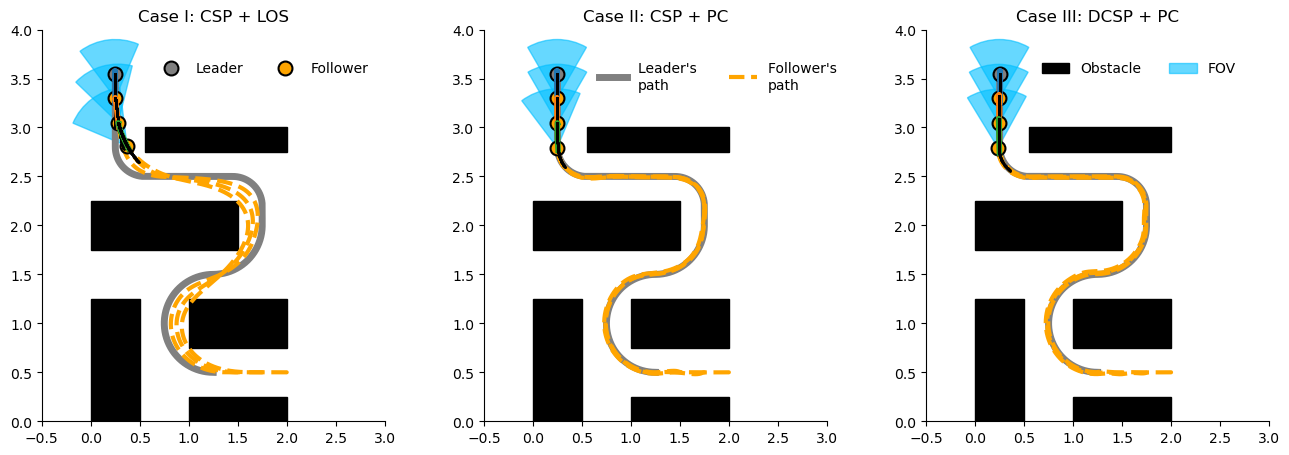

In [14]:
"""Animate the simulation"""

def is_point_in_fov(pre_bot_pos, bot_pos, start_angle, end_angle, l=0.6):
    dx = pre_bot_pos[0] - bot_pos[0]
    dy = pre_bot_pos[1] - bot_pos[1]

    if np.linalg.norm([dx, dy]) > l:
        return "crimson"
    
    point_angle = (np.degrees(np.arctan2(dy, dx)) + 360) % 360
    if start_angle <= end_angle:
        return "deepskyblue" if start_angle <= point_angle <= end_angle else "crimson"
    
    return "deepskyblue" if point_angle >= start_angle or point_angle <= end_angle else "crimson"

def plot_fov(ax, bot_pos, pre_bot_pos, l = 0.6, phi = 60):
    x, y, theta = bot_pos
    theta_deg = np.degrees(theta)  # convert orientation to degrees
    start_angle = (theta_deg - phi/2 + 360) % 360
    end_angle   = (theta_deg + phi/2 + 360) % 360
    fov_patch = patches.Wedge((x, y), l,
                               start_angle, 
                               end_angle, 
                               color = is_point_in_fov(pre_bot_pos, 
                                                       bot_pos,
                                                       start_angle,
                                                       end_angle), 
                               label = 'FOV',
                               alpha = 0.6)
    ax.add_patch(fov_patch)

# Function to plot black patches for static obstacles
def plot_obstacle(ax, vertices):
    bottom_left, top_right = vertices[0], vertices[1]
    obstacle = patches.Rectangle(bottom_left,
                                 top_right[0] - bottom_left[0], 
                                 top_right[1] - bottom_left[1], 
                                 color = 'black', 
                                 label = 'Obstacle',
                                 alpha = 1.0)
    ax.add_patch(obstacle)

def plot_positions(ax, bots_pos, title):
    # Plot leader trajectory and current position
    ax.plot(leader_pos[:, 0], leader_pos[:, 1], linewidth=5, color=colors[0], label="Leader's \npath")
    ax.plot(leader_pos[playback * i, 0], leader_pos[playback * i, 1], 'o', markersize=10,
            color=colors[0], markeredgecolor='black', markeredgewidth=1.5, label='Leader')

    # Plot each bot's trajectory, current position, and its FOV
    for k, bot in enumerate(bots_pos):
        ax.plot(bot[:, 0], bot[:, 1], linestyle='--', linewidth=3, color=colors[1], label="Follower's \npath")

        # bot & pre_bot [x, y, theta] at current time
        bot_pos_i = bot[playback * i]  
        pre_bot = bots_pos[k - 1] if k != 0 else leader_pos
        pre_bot_pos_i = pre_bot[playback * i]

        ax.plot(bot_pos_i[0], bot_pos_i[1], 'o', markersize=10, color=colors[1], 
                markeredgecolor='black', markeredgewidth=1.5, label="Follower")
        
        # Plot the FOV for the bot
        plot_fov(ax, bot_pos_i, pre_bot_pos_i)

    ax.set_xlim(-0.5, 3.0)
    ax.set_ylim(0, 4.0)
    # ax.axis("equal")
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title)


def plot_obs_traj(ax, bots_obs, bots_traj):
    for bot_obs, bot_traj in zip(bots_obs, bots_traj):
        ax.plot(bot_traj[playback * i][:, 0], bot_traj[playback * i][:, 1], linewidth=4)
        ax.plot(bot_obs[playback * i][:, 0], bot_obs[playback * i][:, 1], 'k.', markersize=2)

def legend(axs, lengend_loc = (0.3, 0.95)):
    ax1, ax2, ax3 = axs

    for ax in axs:
        ax.spines['top'].set_visible(False)     
        ax.spines['right'].set_visible(False)

    # Remove duplicate legend entries
    handles1, labels1 = ax1.get_legend_handles_labels()
    unique_labels1 = {"Leader": handles1[labels1.index("Leader")], 
                    "Follower": handles1[labels1.index("Follower")]} 
    handles2, labels2 = ax2.get_legend_handles_labels()
    unique_labels2 = {"Leader's \npath": handles2[labels2.index("Leader's \npath")], 
                    "Follower's \npath": handles2[labels2.index("Follower's \npath")]}
    handles3, labels3 = ax3.get_legend_handles_labels()
    unique_labels3 = {"Obstacle": handles3[labels3.index("Obstacle")],
                    "FOV": handles3[labels3.index("FOV")],}

    ax1.legend(unique_labels1.values(), unique_labels1.keys(), frameon=False, bbox_to_anchor=lengend_loc, ncol=2)
    ax2.legend(unique_labels2.values(), unique_labels2.keys(), frameon=False, bbox_to_anchor=lengend_loc, ncol=2)
    ax3.legend(unique_labels3.values(), unique_labels3.keys(), frameon=False, bbox_to_anchor=lengend_loc, ncol=2)

# Animation settings
playback = 25
colors = ['gray', 'orange', 'deepskyblue']
obstacles = [[(0.0, 0.0), (0.5, 1.25)],
             [(1.0, 0.0), (2.0, 0.25)],
             [(1.0, 0.75), (2.0, 1.25)],
             [(0.0, 1.75), (1.5, 2.25)],
             [(0.55, 2.75), (2.0, 3.0)]]

# Animation loop
for i in range(len(source_trajectory) // playback):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 6))

    # Plot positions for different scenarios
    plot_positions(ax1, bots_reg_pos, "Case I: CSP + LOS")
    plot_positions(ax2, bots_pds_pos, "Case II: CSP + PC")
    plot_positions(ax3, bots_dsr_pos, "Case III: DCSP + PC")

    # Plot obstacles and observation trajectories
    plot_obs_traj(ax1, bots_reg_obs, reg_fit_traj)
    plot_obs_traj(ax2, bots_pds_obs, pds_fit_traj)
    plot_obs_traj(ax3, bots_dsr_obs, dsr_fit_traj)

    for obstacle in obstacles:
        plot_obstacle(ax1, obstacle)
        plot_obstacle(ax2, obstacle)
        plot_obstacle(ax3, obstacle)

    legend((ax1, ax2, ax3))
    plt.tight_layout()
    
    display.clear_output(wait=True)
    display.display(plt.gcf())
    plt.close(fig)
